#Final Model (ANN for Total MSW)

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import random
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

##Load the dataset

In [ ]:
# Load dataset
df = pd.read_excel("DataSetSW_ANN.xlsx")
df.head()

,GDP,Population,GDP/Capita,Literacy Rate,Urban Population %,HH Size,Total_MSW_tons/year,MSW_tons/Capita/year,Organic%,Paper%,Plastic%,Metal%,Glass%,E waste %
0,3.917108e+10,2854191,13724.058594,99.0,65.000000,3.950000,1.087447e+06,0.381000,51.4,9.9,9.6,4.8,4.5,1.839171
1,4.802139e+11,40606052,11826.165039,81.4,75.000000,4.940000,1.237874e+07,0.304850,54.4,9.8,16.9,2.8,1.2,2.035748
2,6.178963e+08,55599,11113.442383,97.0,61.386364,4.182885,1.898949e+04,0.341544,19.7,26.4,12.8,7.9,3.4,0.000000
3,3.603207e+09,82431,43711.800781,100.0,88.000000,3.637898,4.300000e+04,0.521648,31.2,35.1,11.3,2.6,8.2,0.000000
4,2.016900e+11,25096150,8036.690430,72.0,64.500000,6.450000,4.213644e+06,0.167900,51.8,11.9,13.5,4.4,6.7,2.183384


##For reproducibility

In [ ]:
# Set seeds for reproducibility
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Reset Keras session
K.clear_session()

# Force deterministic operations
os.environ["TF_DETERMINISTIC_OPS"] = "1"

##Correlation Analysis

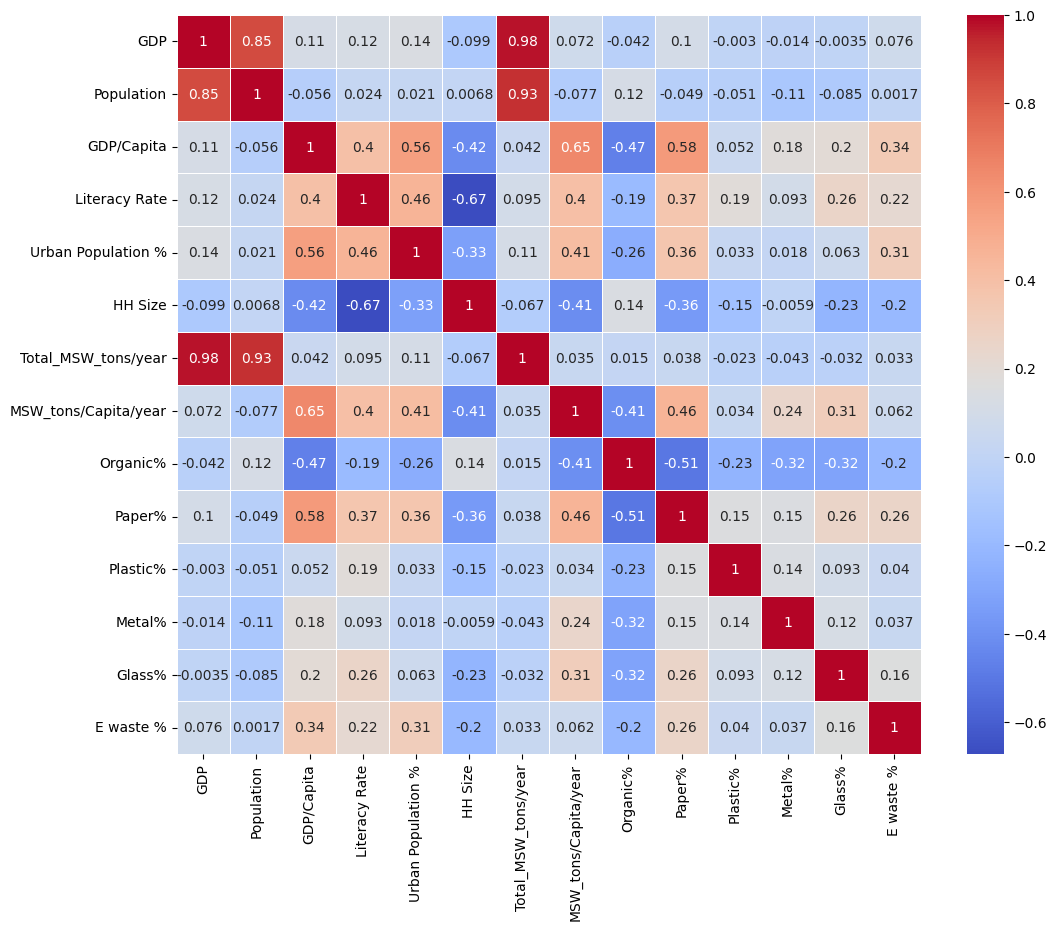

In [ ]:
# Correlation analysis
plt.figure(figsize=(12, 9.6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
#plt.title('Correlation Matrix')
plt.show()

##Feature Selection

In [ ]:
# Define input parameters explicitly (adjust this list as per your dataset)
input_features = ["GDP", "Population", "GDP/Capita", "Literacy Rate",
                  "Urban Population %", "HH Size"]

# Selecting top correlated features with target from input features only
target = "Total_MSW_tons/year"
feature_corr = df[input_features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
top_features = feature_corr.index[:6]  # Select top 6 input features
X = df[top_features].values
Y = df[target].values


##Normalization

In [ ]:
# # Standardizing features
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)
scaler_Y = StandardScaler()
Y = scaler_Y.fit_transform(Y.reshape(-1,1)) #if, to normalize the target value
# Y = np.log(Y.reshape(-1, 1)) #if, to log trasform the target value
# Y = scaler.fit_transform(np.log(Y.reshape(-1, 1))) #if, to log transform and normalize the target value

##Model training and hyperparameter search

###Optimizing R2

In [ ]:
# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

# Hyperparameter search space
num_layers_range = [5]    # Search for number of layers from 2 to 16
num_neurons_range = [162]  # Search for neurons per layer

best_r2 = -np.inf
best_params = {}

for num_layers in num_layers_range:
    for num_neurons in num_neurons_range:
        temp_r2_scores = []

        for train_index, test_index in kf.split(X):
            X_train, X_test = X[train_index], X[test_index]
            Y_train, Y_test = Y[train_index], Y[test_index]

            # Define ANN model
            model = Sequential()
            model.add(Dense(num_neurons, activation='relu', input_shape=(X_train.shape[1],)))
            for _ in range(num_layers - 1):
                model.add(Dense(num_neurons, activation='relu'))
            model.add(Dense(1))

            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

            # Train model with early stopping
            early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
            model.fit(X_train, Y_train, epochs=100, batch_size=10, verbose=0, callbacks=[early_stopping])

            # Evaluate model
            Y_pred = model.predict(X_test)
            r2 = r2_score(Y_test, Y_pred)
            temp_r2_scores.append(r2)

        avg_r2 = np.mean(temp_r2_scores)
        if avg_r2 > best_r2:
            best_r2 = avg_r2
            best_params = {'num_layers': num_layers, 'num_neurons': num_neurons}

# Print best hyperparameters and R² score
print(f'Best R² score: {best_r2:.4f}')
print(f'Best Hyperparameters: {best_params}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Best R² score: 0.9486
Best Hyperparameters: {'num_layers': 5, 'num_neurons': 162}


###For Actual Vs Predicted Values

In [ ]:
# Store final results
all_actual = []
all_predicted = []

# Re-run KFold using best hyperparameters
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # Keep original target for comparison
    y_test_original = y[test_index]

    # Define model using best parameters
    model = Sequential()
    model.add(Dense(best_params['num_neurons'], activation='relu', input_shape=(X_train.shape[1],)))
    for _ in range(best_params['num_layers'] - 1):
        model.add(Dense(best_params['num_neurons'], activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model.fit(X_train, Y_train, epochs=100, batch_size=10, verbose=0, callbacks=[early_stopping])

    # Predict (scaled space)
    Y_pred = model.predict(X_test)

    # --------- INVERSE TRANSFORMATION ---------
    y_pred = scaler_Y.inverse_transform(Y_pred)   # back to original scale
    y_pred = y_pred.flatten()
    # -----------------------------------------

    # Store results
    all_actual.extend(y_test_original)
    all_predicted.extend(y_pred)

# Create DataFrame
results_df = pd.DataFrame({
    'Actual': all_actual,
    'Predicted': all_predicted,
    'Error': np.array(all_actual) - np.array(all_predicted),
    'Absolute Error': np.abs(np.array(all_actual) - np.array(all_predicted)),
    'Error %': np.abs(np.array(all_actual) - np.array(all_predicted))*100/np.array(all_actual)
})

# Display results
print(results_df)

# Save to CSV (optional)
results_df.to_csv('actual_vs_predicted.csv', index=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
           Actual     Predicted         Error  Absolute Error       Error %
0    5.219716e+06  5.279175e+06 -5.945950e+04    5.945950e+04      1.139133
1    9.519430e+05  3.031973e+06 -2.080030e+06    2.080030e+06    218.503613
2    4.280000e+06  5.009658e+06 -7.296585e+05    7.296585e+05     17.048096
3    4.765883e+06  5.890789e+06 -1.124906e+06    1.124906e+06     23.603307
4    6.859360e+05  4.917399e+06 -4.231463e+06    4.231463e+06    616.888883
..            ...           ...           ...             ...           ...
156  3.989486e+03  1.393161e+06 -1.389172e+06    1.389172e+06  34820.816250
157  3.077114e+07  3.169304e+07 -9.218980e+05    9.218980e+05      2.995983
158  7.022549e+04 -2.144617e+05  2.846872e+05    2.846872e+05    405.390139
159  1.387000e+06  1.418684e+06 -3.168425e+04    3.168425e+04      2.284373
160  1.449752e+06  7.955933e+05  6.541587e+05    6.541587e+05     45.122110

[161 rows x 5 columns]


##Training Vs Validation Loss

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0263 - val_loss: 0.0048
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0211 - val_loss: 0.0036
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0029 - val_loss: 0.0054
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0071 - val_loss: 0.0039
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0030 - val_loss: 0.0037
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0016 - val_loss: 0.0036
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 0.0037
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012 - val_lo

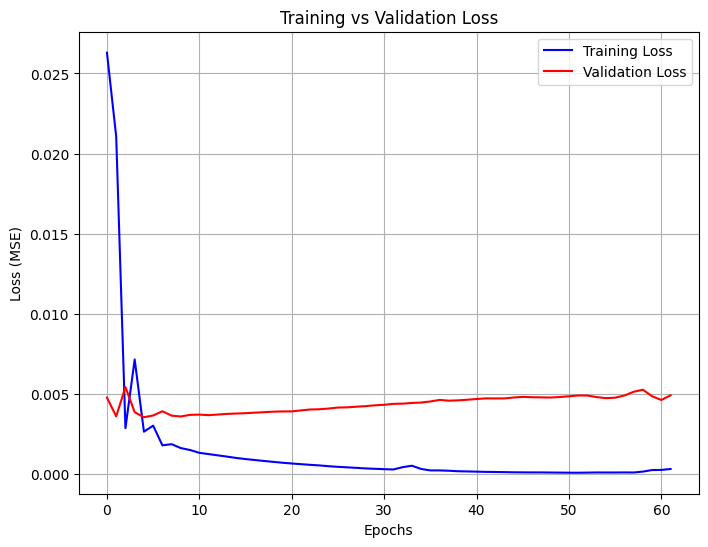

In [ ]:
import matplotlib.pyplot as plt

# Train model with history tracking
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=20,
    verbose=1,
    validation_data=(X_test, Y_test),
    callbacks=[early_stopping]
)

# Plot training vs validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


##Evaluation Matrices

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(Y_true, Y_pred):
    return np.mean(np.abs((Y_true - Y_pred) / Y_true)) * 100

# Initialize lists to store results
metrics_list = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # Define and train the ANN model
    model = Sequential()
    model.add(Dense(best_params['num_neurons'], activation='relu', input_shape=(X_train.shape[1],)))
    for _ in range(best_params['num_layers'] - 1):
        model.add(Dense(best_params['num_neurons'], activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model.fit(X_train, Y_train, epochs=100, batch_size=10, verbose=0, callbacks=[early_stopping])

    # Predictions
    Y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, Y_pred)
    mape = mean_absolute_percentage_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    metrics_list.append([mse, rmse, mae, mape, r2])

# Create DataFrame for tabulated results
metrics_df = pd.DataFrame(metrics_list, columns=['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²'])
print(metrics_df)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
        MSE      RMSE       MAE   MAPE (%)        R²
0  0.094049  0.306675  0.109506  20.865882  0.934307
1  0.016621  0.128922  0.057325  24.461429  0.884135
2  0.003202  0.056583  0.043371  22.556653  0.979649
3  0.008744  0.093508  0.061622  30.695073  0.997179
4  0.002525  0.050246  0.036775  26.594673  0.949856


#Response Curve

##Colorful

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


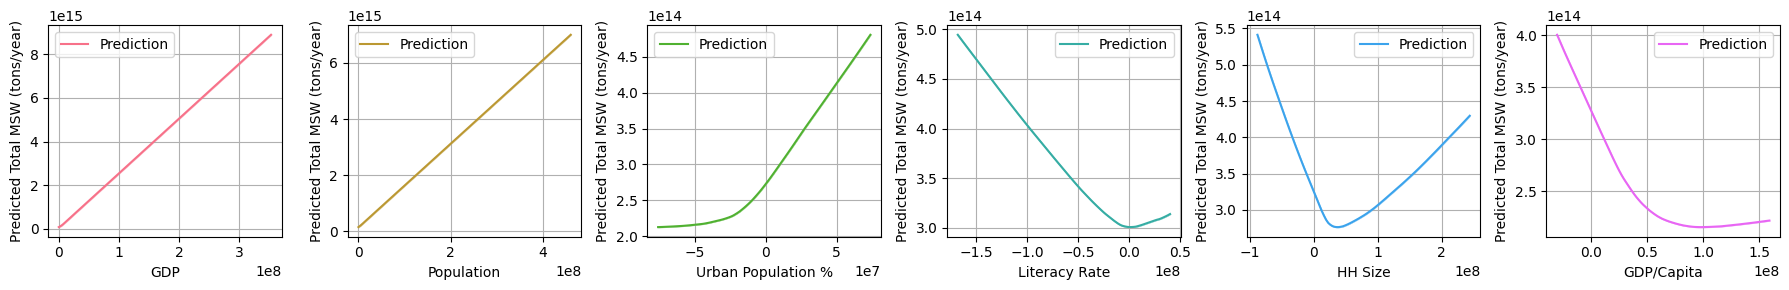

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Generate response curves for each feature
def plot_response_curves(model, X, feature_names, scaler):
    plt.figure(figsize=(18, 3))
    num_features = X.shape[1]
    mean_values = np.mean(X, axis=0)
    colors = sns.color_palette("husl", num_features)  # Get distinct colors

    for i in range(num_features):
        plt.subplot(1, num_features, i + 1)
        X_varied = np.tile(mean_values, (100, 1))  # Keep all other variables constant
        X_varied[:, i] = np.linspace(np.min(X[:, i]), np.max(X[:, i]), 100)  # Vary one feature

        # Inverse scale the inputs before prediction
        X_varied_original = scaler.inverse_transform(X_varied)  # Inverse transform the input

        # Make predictions using the model
        predictions = model.predict(X_varied)
        mean_pred = np.mean(predictions, axis=1)
        std_pred = np.std(predictions, axis=1)

        # Inverse scale the outputs before plotting
        mean_pred_original = inverse_transform_output(scaler, mean_pred)  # Inverse transform the output
        ci_lower = inverse_transform_output(scaler, mean_pred - 2.576 * std_pred)
        ci_upper = inverse_transform_output(scaler, mean_pred + 2.576 * std_pred)


        # Plotting the response curve
        plt.plot(X_varied_original[:, i], mean_pred_original, label='Prediction', color=colors[i])
        plt.fill_between(X_varied_original[:, i], ci_lower, ci_upper, color=colors[i], alpha=0.3)  # 99% CI shading
        plt.xlabel(feature_names[i])
        plt.ylabel("Predicted Total MSW (tons/year)")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Inverse transform function for output variable
def inverse_transform_output(scaler, values):
    return values * scaler.scale_[-1] + scaler.mean_[-1]

# Train the best ANN model
best_model = Sequential()
best_model.add(Dense(best_params['num_neurons'], activation='relu', input_shape=(X.shape[1],)))
for _ in range(best_params['num_layers'] - 1):
    best_model.add(Dense(best_params['num_neurons'], activation='relu'))
best_model.add(Dense(1))

best_model.compile(optimizer='adam', loss='mse')
best_model.fit(X, y, epochs=100, batch_size=10, verbose=0)

# Plot response curves
plot_response_curves(best_model, X, top_features, scaler)


##With CI

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


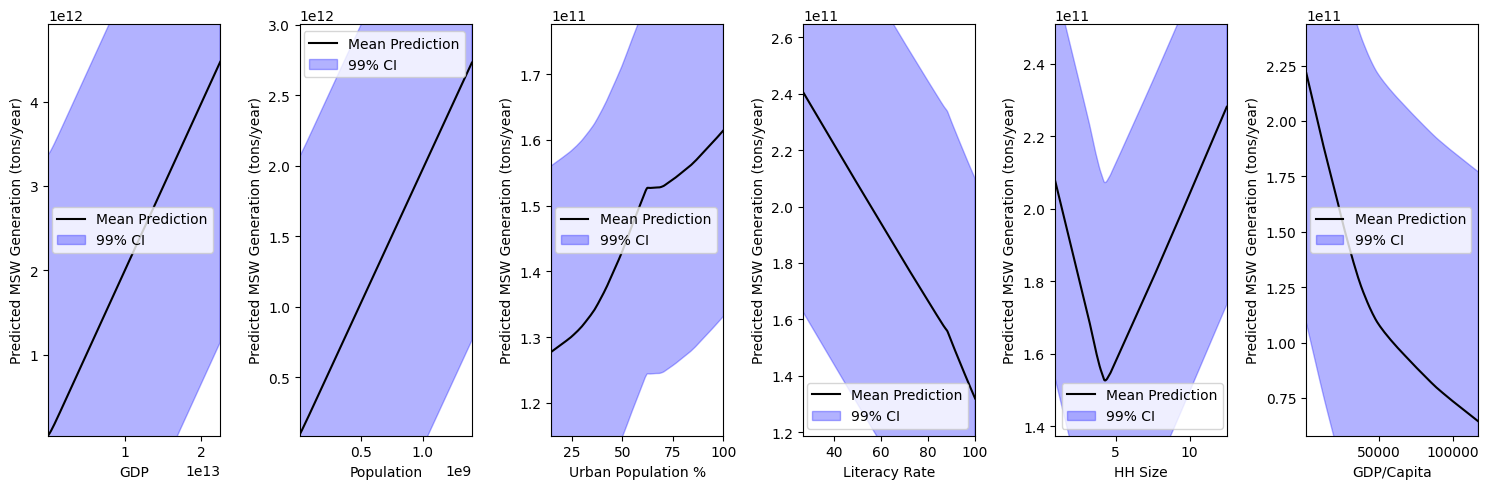

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Inverse transform function for input features
def inverse_transform_feature(scaler, values, feature_idx):
    temp = np.zeros((len(values), scaler.mean_.shape[0]))
    temp[:, feature_idx] = values
    return scaler.inverse_transform(temp)[:, feature_idx]

# Inverse transform function for output variable
def inverse_transform_output(scaler, values):
    return values * scaler.scale_[-1] + scaler.mean_[-1]

# Select best model hyperparameters
best_num_layers = best_params['num_layers']
best_num_neurons = best_params['num_neurons']

# Train the final model
model = Sequential()
model.add(Dense(best_num_neurons, activation='relu', input_shape=(X.shape[1],)))
for _ in range(best_num_layers - 1):
    model.add(Dense(best_num_neurons, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')
model.fit(X, y, epochs=100, batch_size=10, verbose=0)

# Generate response curves
fig, axes = plt.subplots(1, X.shape[1], figsize=(15, 5))

for i, feature in enumerate(top_features):
    x_values = np.linspace(X[:, i].min(), X[:, i].max(), 300).reshape(-1, 1)  # Increased resolution
    x_values_original = inverse_transform_feature(scaler, x_values.flatten(), i)  # Convert back to original scale

    # Keep other features at mean
    X_test = np.tile(np.mean(X, axis=0), (300, 1))
    X_test[:, i] = x_values.flatten()

    # Predict responses
    y_pred_scaled = model.predict(X_test).flatten()
    y_pred = inverse_transform_output(scaler, y_pred_scaled)  # Convert back to real-world scale

    # # Compute 95% confidence intervals
    # y_std = np.std(y_pred)
    # ci_lower = y_pred - 1.96 * y_std
    # ci_upper = y_pred + 1.96 * y_std
    # Compute 99% confidence intervals
    y_std = np.std(y_pred)
    ci_lower = y_pred - 2.576 * y_std
    ci_upper = y_pred + 2.576 * y_std


    # Plot response curve
    ax = axes[i]
    ax.plot(x_values_original, y_pred, color='black', label='Mean Prediction')
    ax.fill_between(x_values_original, ci_lower, ci_upper, color='blue', alpha=0.3, label="99% CI")

    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted MSW Generation (tons/year)")
    # ax.set_title(f"Response Curve: {feature}")

    # Adjust x and y scale for better representation
    ax.set_xlim(min(x_values_original), max(x_values_original))  # Ensure full range is covered
    ax.set_ylim(min(y_pred) * 0.9, max(y_pred) * 1.1)

    ax.legend()

plt.tight_layout()
plt.show()


#To compare R2 of training and testing in each fold

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


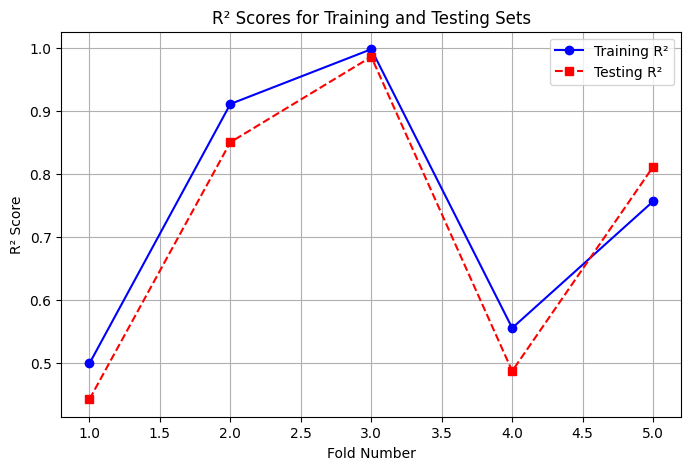

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Lists to store R² scores
train_r2_scores = []
test_r2_scores = []

# K-Fold Cross-Validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # Define ANN model
    model = Sequential()
    model.add(Dense(best_params['num_neurons'], activation='relu', input_shape=(X_train.shape[1],)))
    for _ in range(best_params['num_layers'] - 1):
        model.add(Dense(best_params['num_neurons'], activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    # Train model
    history = model.fit(X_train, Y_train, epochs=100, batch_size=10, verbose=0, callbacks=[early_stopping])

    # Predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    # Calculate R² scores
    train_r2 = r2_score(Y_train, Y_train_pred)
    test_r2 = r2_score(Y_test, Y_test_pred)

    # Store scores
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

# Plot R² Scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_r2_scores) + 1), train_r2_scores, marker='o', linestyle='-', color='b', label='Training R²')
plt.plot(range(1, len(test_r2_scores) + 1), test_r2_scores, marker='s', linestyle='--', color='r', label='Testing R²')

plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.title('R² Scores for Training and Testing Sets')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Available keys in history: dict_keys(['loss', 'val_loss'])


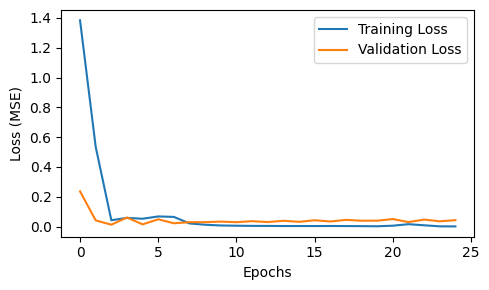

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score

# Assuming X and Y are defined (as NumPy arrays)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store R² scores
train_r2_scores = []
test_r2_scores = []

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

# K-Fold Cross-Validation
for train_index, test_index in kf.split(X):
    X_train_full, X_test = X[train_index], X[test_index]
    Y_train_full, Y_test = Y[train_index], Y[test_index]

    # Create validation set from training data
    X_train, X_val, Y_train, Y_val = train_test_split(X_train_full, Y_train_full, test_size=0.2, random_state=42)

    # Define ANN model
    model = Sequential()
    model.add(Dense(best_params['num_neurons'], activation='relu', input_shape=(X_train.shape[1],)))
    for _ in range(best_params['num_layers'] - 1):
        model.add(Dense(best_params['num_neurons'], activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    # Train model with validation set
    history = model.fit(X_train, Y_train, epochs=100, batch_size=10,
                        validation_data=(X_val, Y_val), verbose=0, callbacks=[early_stopping])

    # Predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    # Calculate R² scores
    train_r2 = r2_score(Y_train, Y_train_pred)
    test_r2 = r2_score(Y_test, Y_test_pred)

    # Store scores
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)


# Check available keys in history
print("Available keys in history:", history.history.keys())

# Plot Training and Validation Loss Curves
plt.figure(figsize=(5,3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
#plt.title('Training and Validation Loss Curves')
plt.legend()
plt.tight_layout()
plt.show()
